<a href="https://colab.research.google.com/github/data-geass/machine-learning-practice/blob/main/sklearn%26knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# sklearn и knn метод

попрактикуемся с библиотекой sklearn. и также выведем knn метод в ручную

In [1]:
# загрузим датасет из курса
!gdown 1Q-ev_KbSlyw2kfLL6I9Mu8I4Sgb4RGM7

Downloading...
From: https://drive.google.com/uc?id=1Q-ev_KbSlyw2kfLL6I9Mu8I4Sgb4RGM7
To: /content/possum.csv
100% 5.48k/5.48k [00:00<00:00, 2.19MB/s]


In [2]:
!pip install -q scikit-learn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv('/content/possum.csv')
df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [6]:
# удалим ненужные признаки
df = df.drop(columns = ['case', 'site', 'sex', 'Pop'])

In [7]:
df.isna().sum()

,0
age,2
hdlngth,0
skullw,0
totlngth,0
taill,0
footlgth,1
earconch,0
eye,0
chest,0
belly,0


In [8]:
# параметр inplace=True дает воз-ть не писать "df = ..."
df.dropna(inplace=True)
df

,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...
99,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [9]:
# разделим на признаки и таргет переменную
X = df.drop(columns=['age']).values
y = df['age'].values

In [10]:
# 42 - это ответ на смысл жизни из фильма, просто рандомное число
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle = True, test_size=0.2, random_state = 42)

# Опишу как работает алгоритм KNN метод
1) пришел новый опоссум
2) посчитать евклидово расстояние от его вектор признаков до всех других записей
3) ранжируем по самым близким значениям
4) берем топ 3 и их таргет значения усредняем - это и есть ответ

In [11]:
X_train[0]

array([89.2, 54. , 82. , 38. , 63.8, 44.9, 12.8, 24. , 31. ])

In [12]:
X_test[0]

array([89.6, 58. , 87.5, 38. , 66.7, 43.5, 16. , 25.5, 31.5])

In [13]:
from math import sqrt

# Евклидово расстояние между двумя векторами
def euclidean_distance(vec1, vec2):
  distance = 0.0
  for i in range(len(vec1)):
    distance += (vec1[i] - vec2[i])**2
  return sqrt(distance)

In [14]:
euclidean_distance(X_train[0], X_test[0])

8.337865434270332

In [15]:
X_test[1]

array([102.5,  62.8,  96. ,  40. ,  73.2,  44.5,  14.7,  32. ,  36. ])

In [16]:
X_train[:5]

array([[89.2, 54. , 82. , 38. , 63.8, 44.9, 12.8, 24. , 31. ],
       [90.5, 54.5, 85. , 35. , 70.3, 50.8, 14.2, 23. , 28. ],
       [90.7, 55.9, 81. , 34. , 71.5, 54. , 14.6, 27. , 31.5],
       [88.7, 52. , 83. , 38. , 61.5, 45.9, 14.7, 26. , 34. ],
       [91.6, 56. , 86. , 34.5, 73. , 51.4, 14.4, 28. , 32. ]])

In [17]:
# найдем соседей
def get_neighbors(train, test_row, num_neighbors):
  distances = []
  for train_id, train_row in enumerate(train):
    dist = euclidean_distance(test_row, train_row)
    distances.append((train_id, dist))

  distances.sort(key=lambda x: x[1])

  nearest_ids = []
  for i in range(num_neighbors):
    nearest_ids.append(distances[i][0])

  return nearest_ids

In [18]:
get_neighbors(X_train[:5], X_test[1], 3)

[4, 1, 2]

In [19]:
# предиктим
def predict(X_train, X_test, y_train, num_neighbors = 3):
  y_pr = []
  for x_test in X_test:
    nearest_ids = get_neighbors(X_train, x_test, num_neighbors)
    y_preds = y_train[nearest_ids]
    y_preds = y_preds.mean()
    y_pr.append(y_preds)
  return y_pr

In [20]:
y_pr = predict(X_train[:30], X_test[:5], y_train[:30], num_neighbors = 5)
y_pr

[np.float64(3.4),
 np.float64(4.0),
 np.float64(3.6),
 np.float64(4.0),
 np.float64(4.6)]

# Теперь сделаем с пом-ю sklearn

In [21]:
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([3.4, 4. , 3.4, 3.6, 4.6, 3. , 5.4, 5.2, 5. , 5.2, 4. , 5.8, 3.2,
       3. , 4.4, 4.2, 3.6, 2.8, 5.6, 6. , 2.4])

# Далее займемся оценкой модели


In [22]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [23]:
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

In [24]:
MSE_train = mean_squared_error(y_train, pred_train)
RMSE_train = sqrt(MSE_train)
R2_train = r2_score(y_train, pred_train)
MAE_train = mean_absolute_error(y_train, pred_train)

In [25]:
print(f'MSE на обучении {MSE_train:.2f}\n')
print(f'RMSE на обучении {RMSE_train:.2f}\n')
print(f'R2 на обучении {R2_train:.2f}\n')
print(f'MAE на обучении {MAE_train:.2f}')

MSE на обучении 2.24

RMSE на обучении 1.50

R2 на обучении 0.34

MAE на обучении 1.24


In [26]:
MSE_test = mean_squared_error(y_test, pred_test)
RMSE_test = sqrt(MSE_test)
R2_test = r2_score(y_test, pred_test)
MAE_test = mean_absolute_error(y_test, pred_test)

In [27]:
print(f'MSE на тесте {MSE_test:.2f}\n')
print(f'RMSE на тесте {RMSE_test:.2f}\n')
print(f'R2 на тесте {R2_test:.2f}\n')
print(f'MAE на тесте {MAE_test:.2f}')

MSE на тесте 3.83

RMSE на тесте 1.96

R2 на тесте 0.15

MAE на тесте 1.66


 MAE на тесте = 1.6, а RMSE = 1.96.
 Это говорит о том, что были выбросы в ответах модели, так как RMSE > MAE

 На обучение R^2 = 0.34, а на тесте 0.15 -> выходит это переобучение модели, так как на знакомых данных результат лучше



# Далее вспомним Дерево решений
Кстати похоже на символьный подход к ИИ, то есть определенные правила для принятия решения

In [28]:
model1 = DecisionTreeRegressor(random_state=42)
model1.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [29]:
pred_train = model1.predict(X_train)
pred_test = model1.predict(X_test)

MSE_train = mean_squared_error(y_train, pred_train)
RMSE_train = sqrt(MSE_train)
R2_train = r2_score(y_train, pred_train)
MAE_train = mean_absolute_error(y_train, pred_train)

MSE_test = mean_squared_error(y_test, pred_test)
RMSE_test = sqrt(MSE_test)
R2_test = r2_score(y_test, pred_test)
MAE_test = mean_absolute_error(y_test, pred_test)

In [30]:
print(f'MSE на обучении {MSE_train:.2f}\n')
print(f'RMSE на обучении {RMSE_train:.2f}\n')
print(f'R2 на обучении {R2_train:.2f}\n')
print(f'MAE на обучении {MAE_train:.2f}')

MSE на обучении 0.00

RMSE на обучении 0.00

R2 на обучении 1.00

MAE на обучении 0.00


In [31]:
print(f'MSE на тесте {MSE_test:.2f}\n')
print(f'RMSE на тесте {RMSE_test:.2f}\n')
print(f'R2 на тесте {R2_test:.2f}\n')
print(f'MAE на тесте {MAE_test:.2f}')

MSE на тесте 3.00

RMSE на тесте 1.73

R2 на тесте 0.34

MAE на тесте 1.29


Видим что ошибки в обучении идеальные, хотя на тесте ошибки большие -> модель переобучилась

# Борьба с переобучением

Увеличение данных в обучение.
Если данных мало -> можно использовать Кросс-валидацию и в конце просто усреднить

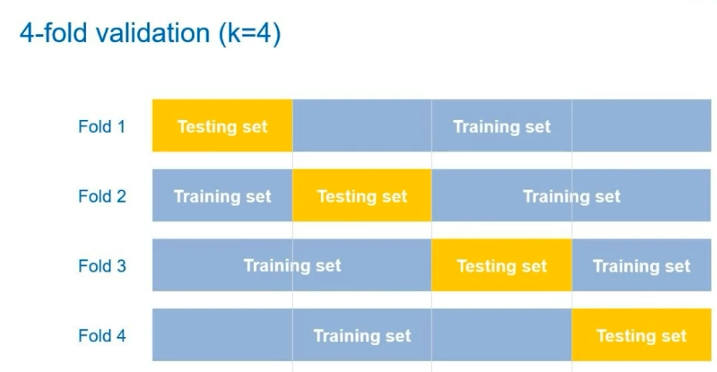

In [32]:
from sklearn.model_selection import cross_validate

scores = cross_validate(model, X, y, cv=5, scoring='r2')

**Другой метод это подбор гиперпараметров и GridSearchCV**

Например, в дереве решений - это глубина дерева/максимальное кол-во листьев

In [35]:
model1.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
model = DecisionTreeRegressor()

In [39]:
param = {
    'max_depth': np.arange(1,5),
    'min_samples_leaf': [1, 2, 3]
}

In [44]:
gridsearch = GridSearchCV(model, param, refit=True, scoring='r2')
gridsearch.fit(X_train, y_train)

print(gridsearch.best_params_)

{'max_depth': np.int64(1), 'min_samples_leaf': 1}


# Сохранить модели

In [45]:
import pickle

filename = 'model.sav'
pickle.dump(model, open(filename, 'wb'))

# а загрузить сл образом
loaded_model = pickle.load(open(filename, 'rb'))